# Nonlinear expressions

Models can describe responses with nonlinear functions. These functions are often motivated by theory, and their form gives each parameter a direct interpretation.

Bambi lets us write that relationship as a formula and model each free parameter with its own
formula. In this notebook, we use two classical examples to demonstrate the workflow:
Michaelis-Menten enzyme kinetics and logistic tree growth.

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("bambi.mplstyle")


## Michaelis-Menten enzyme kinetics

The `Puromycin` dataset contains reaction rates measured at several substrate concentrations for
treated and untreated cells. It is described in the
[`datasets` documentation](https://search.r-project.org/R/refmans/datasets/html/Puromycin.html).

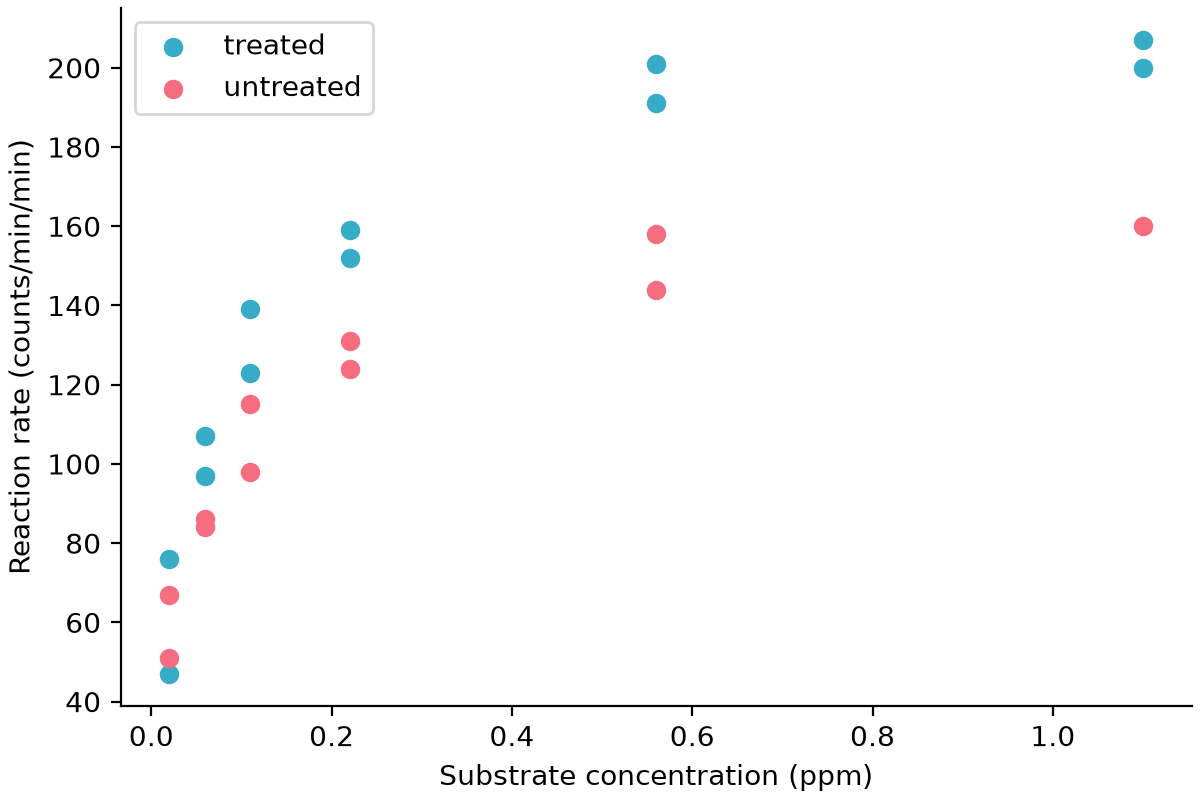

In [2]:
puromycin = pd.read_csv("data/puromycin.csv")
puromycin["state"] = puromycin["state"].astype("category")

for state, group in puromycin.groupby("state", observed=True):
    plt.scatter(group["concentration"], group["rate"], label=state)
plt.xlabel("Substrate concentration (ppm)")
plt.ylabel("Reaction rate (counts/min/min)")
plt.legend()
plt.show()


The Michaelis-Menten curve is

$$
\operatorname{rate}_i =
\frac{V_{\max,i} c_i}{K_{m,i} + c_i} + \epsilon_i.
$$

$V_{\max}$ is the asymptotic reaction rate and $K_m$ is the concentration at which the expected
rate reaches half of $V_{\max}$. Both parameters can differ between treated and untreated cells.

In Bambi, we use the nonlinear API to model this relationship. The first formula defines the nonlinear mean. The additional formulas use ordinary Formulae syntax to describe each nonlinear parameter. Each nonlinear parameter must be passed to the `nlpars` argument. Here, `0 + state` estimates one coefficient for each treatment state, allowing both $V_{\max}$ and $K_m$ to differ between treated and untreated cells.

In [3]:
reaction_rate_expression = "vmax * concentration / (km + concentration)"
mm_formula = bmb.Formula(
    f"rate ~ {reaction_rate_expression}",
    "vmax ~ 0 + state",
    "km ~ 0 + state",
    nlpars=("vmax", "km"),
)

mm_priors = {
    "vmax": {
        "state": bmb.Prior("LogNormal", mu=np.log(180), sigma=0.4),
    },
    "km": {
        "state": bmb.Prior("LogNormal", mu=np.log(0.1), sigma=0.7),
    },
    "sigma": bmb.Prior("HalfNormal", sigma=30),
}

mm_model = bmb.Model(mm_formula, puromycin, priors=mm_priors)
mm_idata = mm_model.fit(random_seed=123, progressbar=False)

NUTS[nutpie]: [sigma, km_state, vmax_state]


We know that $V_{\max}$ and $K_m$ must be positive, so we assign them `LogNormal` priors. After fitting, we can extract values for each of the parameters for both treated and untreated cells.

In [4]:
az.summary(mm_idata, var_names=["vmax_state", "km_state", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
vmax_state[treated],212.9,7.3,200,220,1863,2242,1.00,0.17,0.13
vmax_state[untreated],161.8,7.8,150,170,1691,2068,1.00,0.19,0.15
km_state[treated],0.0651,0.0088,0.052,0.08,1969,2234,1.00,0.0002,0.00015
km_state[untreated],0.0509,0.0101,0.036,0.068,1708,1865,1.00,0.00024,0.00022
sigma,11.06,1.91,8.5,14,2287,2424,1.00,0.039,0.038


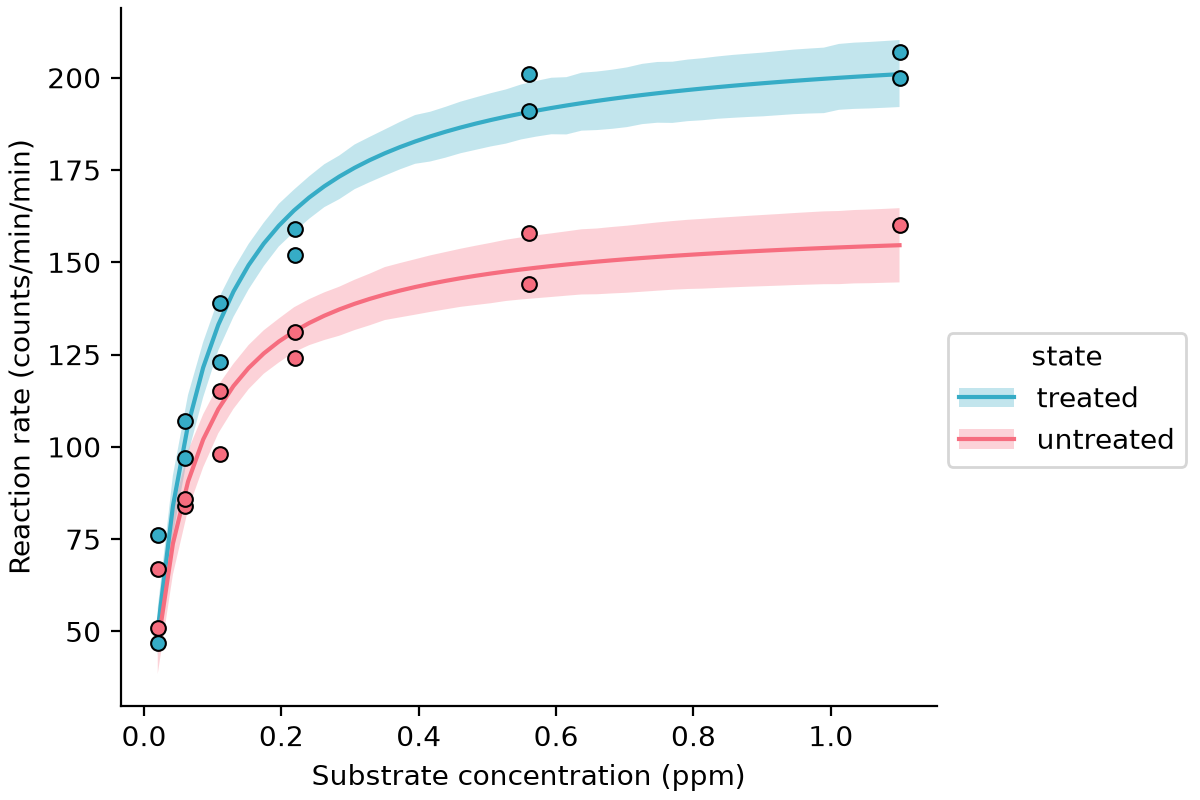

In [5]:
mm_fig = bmb.interpret.plot_predictions(
    mm_model,
    mm_idata,
    conditional=["concentration", "state"],
)
mm_ax = mm_fig.axes[0]
plot_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for (state, group), color in zip(
    puromycin.groupby("state", observed=True), plot_colors
):
    mm_ax.scatter(
        group["concentration"],
        group["rate"],
        facecolors=color,
        edgecolors="black",
        linewidths=0.75,
        s=28,
        zorder=3,
    )
mm_ax.set_xlabel("Substrate concentration (ppm)")
mm_ax.set_ylabel("Reaction rate (counts/min/min)")
mm_fig

The fitted curves capture the nonlinear relationship between substrate concentration and reaction rate for both treatment states. The treated cells have a higher estimated asymptotic reaction rate, and the shape of each curve reflects its state-specific $V_{\max}$ and $K_m$ parameters.


## Logistic growth of orange trees

The `Orange` dataset follows the trunk circumference of five trees at seven ages. Its
[`datasets` documentation](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/Orange.html)
uses the three-parameter logistic growth curve

$$
y_{ij} = \frac{A_j}{1 + \exp((x_{\mathrm{mid}} - x_{ij})/s)} + \epsilon_{ij},
$$

where $A$ is the asymptotic circumference, $x_{\mathrm{mid}}$ is the age at which the tree reaches
half that circumference, and $s$ controls the growth timescale.

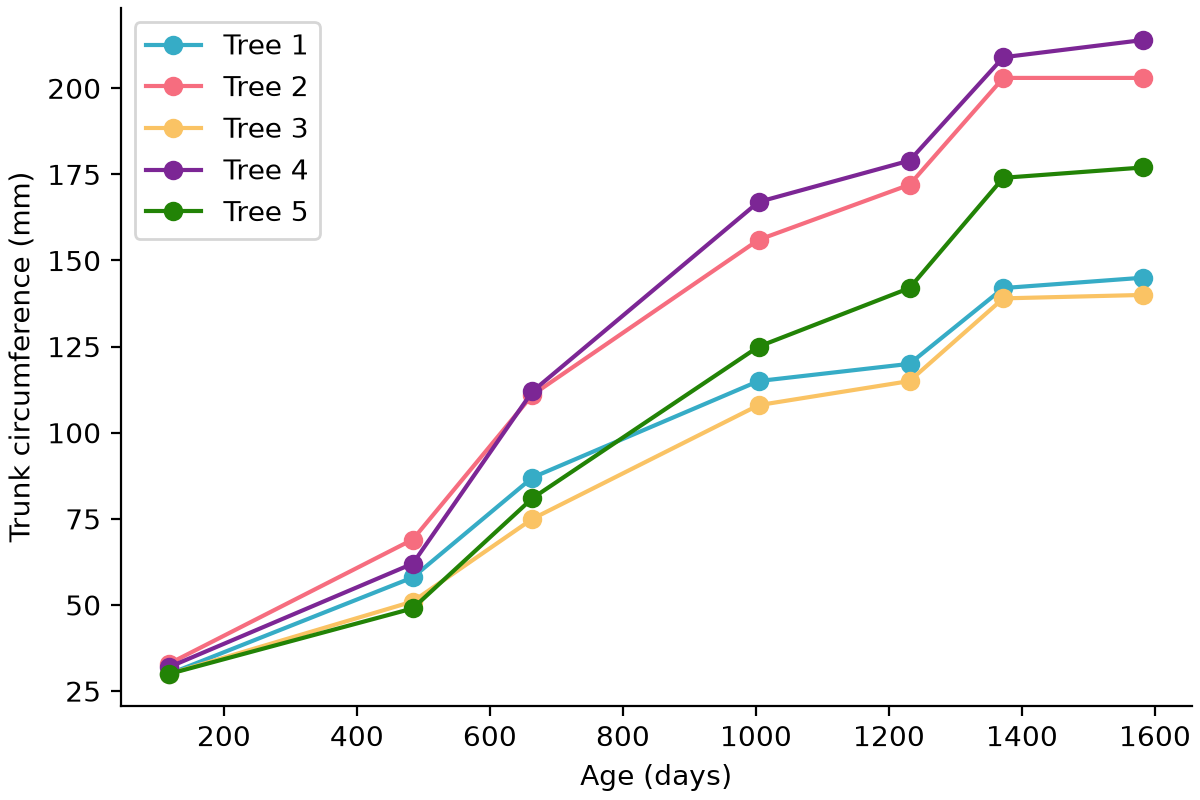

In [6]:
orange = pd.read_csv("data/orange.csv")
orange["age"] = orange["age"].astype(float)
orange["tree"] = orange["tree"].astype("category")

for tree, group in orange.groupby("tree", observed=True):
    plt.plot(group["age"], group["circumference"], "o-", label=f"Tree {tree}")
plt.xlabel("Age (days)")
plt.ylabel("Trunk circumference (mm)")
plt.legend()
plt.show()


Here the asymptote varies by tree while the midpoint and scale are shared. This combines a
nonlinear expression with Bambi's existing group-specific effects machinery.

In [7]:
growth_expression = "asym / (1 + exp((xmid - age) / scale))"
orange_formula = bmb.Formula(
    f"circumference ~ {growth_expression}",
    "asym ~ 1 + (1 | tree)",
    nlpars=("asym", "xmid", "scale"),
)

orange_priors = {
    "asym": {
        "Intercept": bmb.Prior("Normal", mu=190, sigma=30),
        "1|tree": bmb.Prior(
            "Normal",
            mu=0,
            sigma=bmb.Prior("HalfNormal", sigma=30),
        ),
    },
    "xmid": {
        "Intercept": bmb.Prior("Normal", mu=700, sigma=200),
    },
    "scale": {
        "Intercept": bmb.Prior("LogNormal", mu=np.log(350), sigma=0.4),
    },
    "sigma": bmb.Prior("HalfNormal", sigma=20),
}

orange_model = bmb.Model(orange_formula, orange, priors=orange_priors)
orange_idata = orange_model.fit(
    random_seed=123,
    target_accept=0.9,
    progressbar=False,
)

NUTS[nutpie]: [sigma, asym_Intercept, asym_1|tree_sigma, asym_1|tree_offset, scale_Intercept, xmid_Intercept]


We can then evaluate the model across a dense age grid to visualize the fitted growth curves and
their uncertainty.

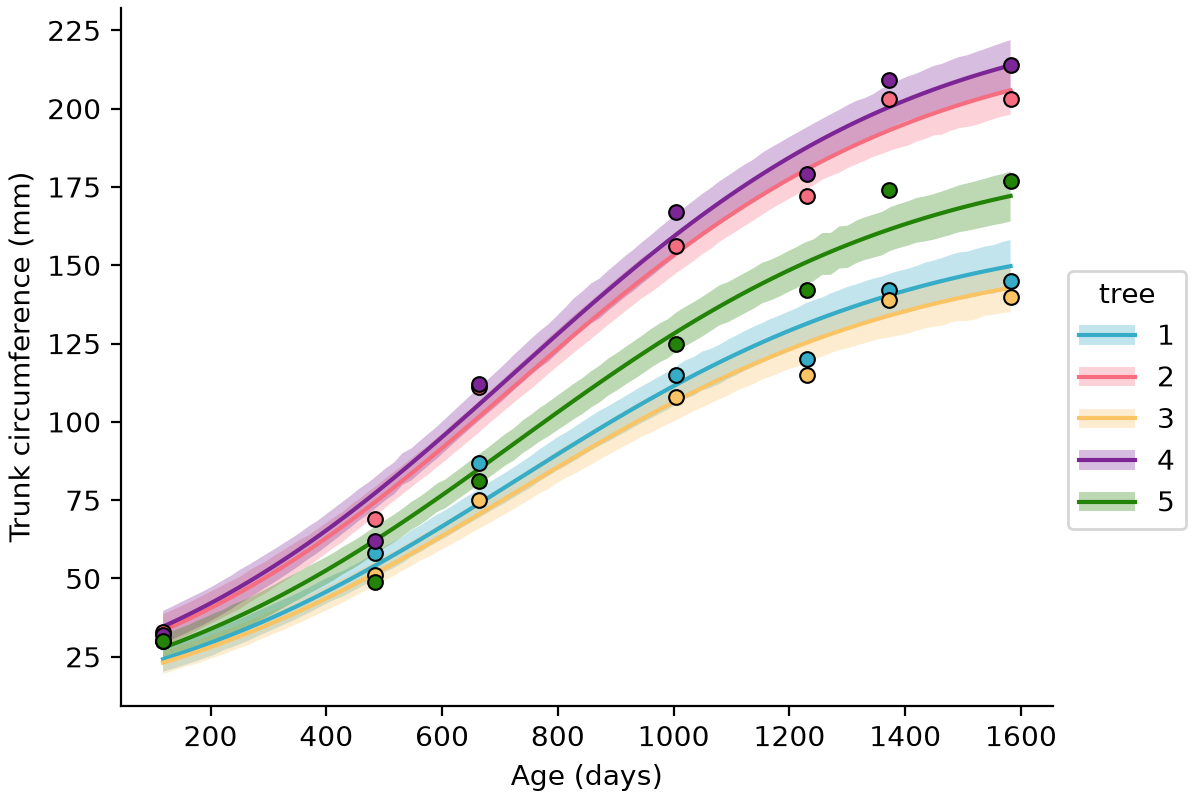

In [8]:
orange_fig = bmb.interpret.plot_predictions(
    orange_model,
    orange_idata,
    conditional={
        "age": np.linspace(orange["age"].min(), orange["age"].max(), 100),
        "tree": orange["tree"].cat.categories.tolist(),
    },
)
orange_ax = orange_fig.axes[0]
for (tree, group), color in zip(orange.groupby("tree", observed=True), plot_colors):
    orange_ax.scatter(
        group["age"],
        group["circumference"],
        facecolors=color,
        edgecolors="black",
        linewidths=0.75,
        s=28,
        zorder=3,
    )
orange_ax.set_xlabel("Age (days)")
orange_ax.set_ylabel("Trunk circumference (mm)")
orange_fig

## Predicting new observations

Prediction uses the same model interface as an ordinary Bambi model. New data only needs the
variables used by the expression and its parameter formulas. For example, we can predict reaction rates for
three new combinations of concentration and treatment state:

In [9]:
new_data = pd.DataFrame(
    {
        "concentration": [0.05, 0.25, 0.75],
        "state": ["treated", "treated", "untreated"],
    }
)
new_predictions = mm_model.predict(
    mm_idata,
    data=new_data,
    inplace=False,
)
new_predictions.predictions

<xarray.DataTree 'predictions'>
Group: /predictions
    Dimensions:  (chain: 4, draw: 1000, __obs__: 3)
    Coordinates:
      * chain    (chain) int64 32B 0 1 2 3
      * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
      * __obs__  (__obs__) int64 24B 0 1 2
    Data variables:
        mu       (chain, draw, __obs__) float64 96kB 93.34 174.6 ... 163.6 147.7
    Attributes:
        created_at:                 2026-10-05T03:22:32.210205+00:00
        creation_library:           ArviZ
        creation_library_version:   1.3.0
        creation_library_language:  Python
        inference_library:          pymc
        inference_library_version:  6.3.2
        sample_dims:                ['chain', 'draw']


The prediction data includes both `concentration`, which appears directly in the nonlinear
expression, and `state`, which determines the group-specific `vmax` and `km` values.

## Composing model parameters

Nonlinear expressions are not limited to the mean of the response. A modeled parameter can be
used inside another expression, including one for an auxiliary family parameter. The
[golf putting example](golf_putting.ipynb) uses this to make the Gaussian residual scale depend on
the fitted success probability.
